# FFNN with TD-IDF

This notebook trains a FFNN to classify a news article into one of 5 bias labels using TF-IDF representations of each news article.

## Import 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import cycle
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from skorch import NeuralNetClassifier

# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

In [2]:
# Load preprocessed data
train = pd.read_csv('train_preprocessed.csv')
test = pd.read_csv('test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

## Weighted FFNN Model

In [3]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train['cleaned_text']).toarray()
X_test = vectorizer.transform(test['cleaned_text']).toarray()

In [4]:
# FFNN Model
# We chose a 3 layer model as LSTM has 3 gates
class FFNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
output_dim = len(label_encoder.classes_)

In [5]:
# Class weights
class_counts = np.bincount(y_train)
class_counts = torch.tensor(class_counts, dtype=torch.float)
weights = 1. / class_counts
weights = weights / weights.sum()

Weight normalization is used here to maintain a consistent overall scale. This prevents disproportionately large loss values for rare classes, which could lead to unstable or overly aggressive gradient updates. By normalizing the weights to sum to 1, the training process remains numerically stable while still emphasizing underrepresented classes.

## Hyperparameter Tuning

In [6]:
# Wrap model for skorch
net = NeuralNetClassifier(
    FFNN,
    module__input_dim=input_dim,
    module__hidden_dim=256,
    module__output_dim=output_dim,
    max_epochs=10,
    lr=1e-3,
    optimizer=optim.Adam,
    criterion=nn.CrossEntropyLoss(weight=weights),
    batch_size=64,
    device=device
)

We fixed the TD-IDF parameters to the same hyper parameters obtained when tuning the decision tree for a fairer comparison between the models

In [7]:
# Grid search parameters
param_grid = {
    'module__hidden_dim': [128, 256, 512],
    'lr': [0.0005, 0.001, 0.01],
    'batch_size': [16, 32, 64],
    'max_epochs': [5, 10]
}

In [8]:
grid = GridSearchCV(net, param_grid, scoring='f1_macro', cv=3, verbose=1)
grid.fit(X_train.astype(np.float32), y_train)

print("Best parameters found:")
print(grid.best_params_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.6101       0.2361        1.6043  1.6924
      2        1.5749       0.5837        1.5583  0.8331
      3        1.4066       0.6352        1.4166  0.8597
      4        0.9857       0.6395        1.2229  0.8864
      5        0.5168       0.6352        1.1214  1.0345
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.6074       0.5107        1.6067  0.9784
      2        1.5877       0.5107        1.5904  0.7820
      3        1.4900       0.5923        1.5321  0.9417
      4        1.1812       0.6695        1.4085  1.1262
      5        0.6784       0.6609        1.2803  0.9633
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.6086     

## Evaluation

In [9]:
# Evaluate best model
best_model = grid.best_estimator_
preds = best_model.predict(X_test.astype(np.float32))
probs = best_model.predict_proba(X_test.astype(np.float32))

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='macro')
report = classification_report(y_test, preds, target_names=label_encoder.classes_, digits=4)

print(f"FFNN Accuracy: {acc * 100:.2f}%")
print(f"FFNN Macro F1-score: {f1:.4f}")
print("\nClassification Report:\n", report)

FFNN Accuracy: 69.34%
FFNN Macro F1-score: 0.6072

Classification Report:
               precision    recall  f1-score   support

      center     0.4902    0.6098    0.5435        41
   lean left     0.5143    0.5902    0.5496        61
  lean right     0.5185    0.3784    0.4375        37
        left     0.8390    0.7748    0.8056       222
       right     0.6667    0.7368    0.7000        76

    accuracy                         0.6934       437
   macro avg     0.6057    0.6180    0.6072       437
weighted avg     0.7039    0.6934    0.6958       437



#### Classification Report Commentary

The FFNN outperforms all decision tree variants in overall accuracy, reaching 69.21% accuracy. However, the macro F1-score (0.5581) remains comparable to the tuned decision tree, indicating that class imbalance still impacts per-class fairness.


- The model performs very well on the majority class:
  - Left: F1 = 0.83
- It also performs reasonably well on a minority class:
  - Right: F1 = 0.66
- Other minority classes remain problematic:
	- Center: F1 = 0.56 
	- Lean left: F1 = 0.48
	- Lean right: F1 = 0.36 (lowest overall)

This shows that while the FFNN is effective overall, it continues to struggle with detecting minority class instances, especially lean right.

### Confusion Matrices

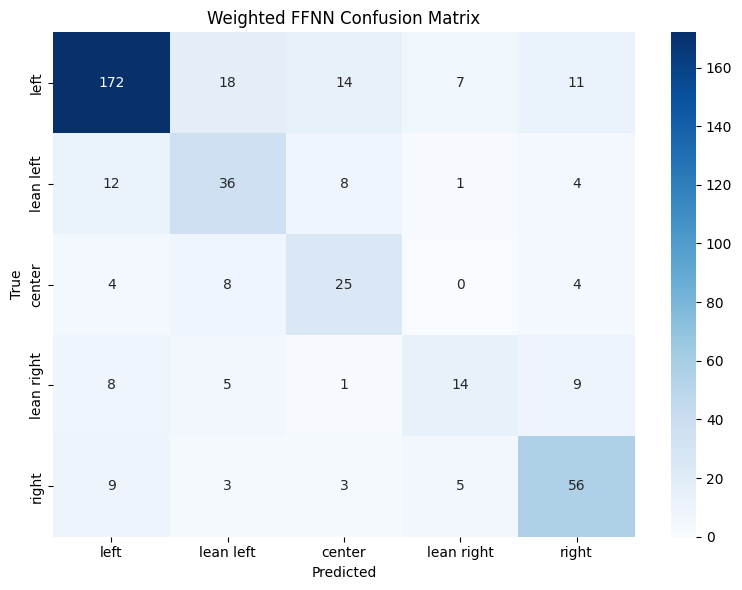

In [10]:
label_order = ['left', 'lean left', 'center', 'lean right', 'right']
label_indices = [np.where(label_encoder.classes_ == label)[0][0] for label in label_order]

#cm = confusion_matrix(y_test_np, y_pred, labels=label_indices)
cm = confusion_matrix(y_test, preds, labels=label_indices)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_order, yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Weighted FFNN Confusion Matrix')
plt.tight_layout()
plt.show()

- The FFNN performs well on the "left" and "right" classes, with 195 and 51 correct predictions respectively, showing strong class identification on the extremes.
- There is still moderate confusion between neighboring classes like "lean left" and "left", and between "lean right" and "right", indicating room for improvement in boundary refinement.
- Compared to decision trees, the FFNN appears more balanced overall but struggles slightly with nuanced central categories like "lean right" and "center".

### ROC-AUC

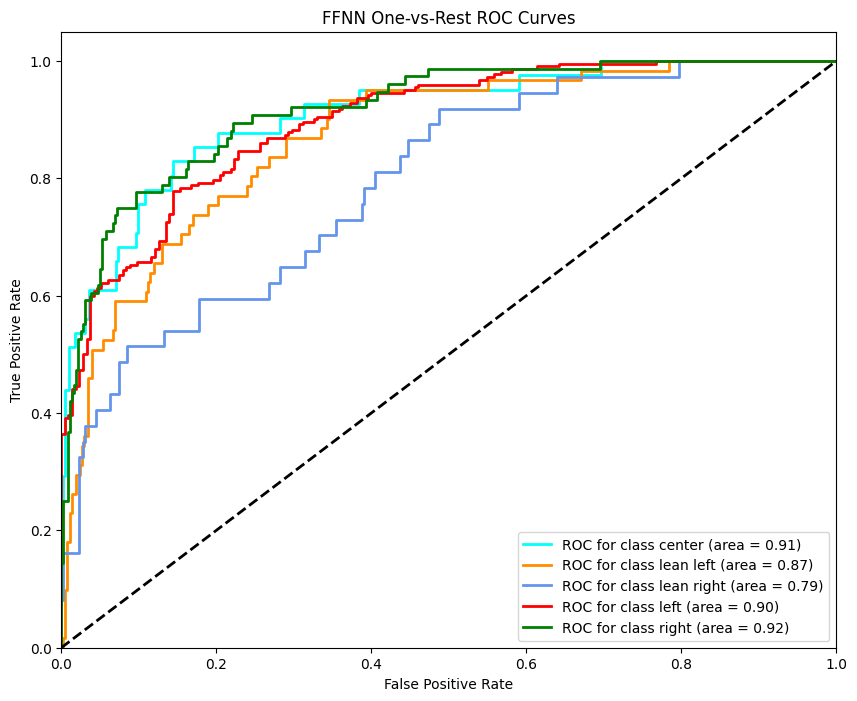

In [11]:
# ROC Curves
y_test_bin = label_binarize(y_test, classes=np.arange(output_dim))
probs = np.array(probs)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(output_dim):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc[i] = roc_auc_score(y_test_bin[:, i], probs[:, i])

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for i, color in zip(range(output_dim), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC for class {label_encoder.classes_[i]} (area = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FFNN One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


In [12]:
macro_auc = roc_auc_score(y_test_bin, probs, average='weighted')
print(f"Macro-average ROC AUC: {macro_auc:.4f}")

Macro-average ROC AUC: 0.8895


ROC-AUC values are consistently strong across all classes:
- Center: 0.90  
- Lean Left: 0.87
- Lean Right: 0.81  
- Left: 0.91  
- Right: 0.93  

The macro-average ROC-AUC for the FFNN is 0.9031, indicating that the model performs consistently well across all classes, regardless of their frequency in the dataset. This suggests that the model has learned good decision boundaries for all classes, even if classification thresholds (affecting precision/recall) are not ideal for minority classes. 

## Final Conclusion

### Performance Metrics Evaluation Summary

| Model Version | Accuracy (%) | Macro F1-score |
|---------------|--------------|----------------|
| Unweighted DT | 65.84        | 0.5658         |
| Weighted DT   | 60.22        | 0.5209         |
| Tuned DT      | 57.53        | 0.5762         |
| FFNN (TF-IDF) | 69.21        | 0.5775         |


### Final Remarks

Overall, the FFNN provides the best performance among all models, with high accuracy and robust AUC across classes. However, it still underperforms on low-support categories. This confirms that neural networks outperform decision trees in raw performance, but still benefit from further balancing techniques (e.g., class weighting or data augmentation).